In [23]:
%pip install numpy pandas seaborn torch torchvision scikit-learn matplotlib graphviz

Note: you may need to restart the kernel to use updated packages.


In [36]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# K-Means is unsupervised, so we won't use train_test_split here
iris = load_iris()
X, y = iris.data[:, 2:], iris.target

# Show classes
print("Features:", iris.feature_names)
print("Classes:", iris.target_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


# Scikit-Learn

In [45]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)

model.fit(X_scaled)

labels = model.labels_
centroids = model.cluster_centers_

In [46]:
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import numpy as np


def cluster_accuracy(y_true, y_pred):
    labels = np.zeros_like(y_pred)
    for i in np.unique(y_pred):
        mask = y_pred == i
        labels[mask] = mode(y_true[mask])[0]
    return accuracy_score(y_true, labels)


acc = cluster_accuracy(y, labels)
print("K-Means Accuracy:", acc)


K-Means Accuracy: 0.96


# Scratch

In [57]:
import numpy as np

# First, we will create a helper function to calculate the Euclidean distance between two points.
def euclidean(point, centroid):
  return np.sqrt(np.sum((point - centroid) ** 2))

In [58]:
from matplotlib import pyplot as plt

def showplot(centroids):
    plt.figure(figsize=(9, 3.5))
    plt.plot(X[:, 0], X[:, 1], "k*", label="Unlabel instance")
    plt.plot(
        [x for x, _ in centroids],
        [y for _, y in centroids],
        "+",
        markersize=10,
    )
    plt.xlabel("Petal length", fontsize=10)
    plt.xlabel("Petal width", fontsize=10)
    plt.legend(fontsize=10)
    plt.show()

In [59]:
# Next, we need a way to initialize the starting point of each centroid.
# We will calculate it by uniformly distributing each centroid in the graph.
from numpy.random import uniform

n_clusters = 3  # The data set have 3 class hench 3 cluster centroids we need to make

minpoint, maxpoint = np.min(X[:, :], axis=0), np.max(X[:, :], axis=0)
centroids = np.array([uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)])
print(minpoint, maxpoint)
print(centroids)

[1.  0.1] [6.9 2.5]
[[2.44015699 2.46348415]
 [3.65456358 2.13384614]
 [2.74810823 1.78206593]]


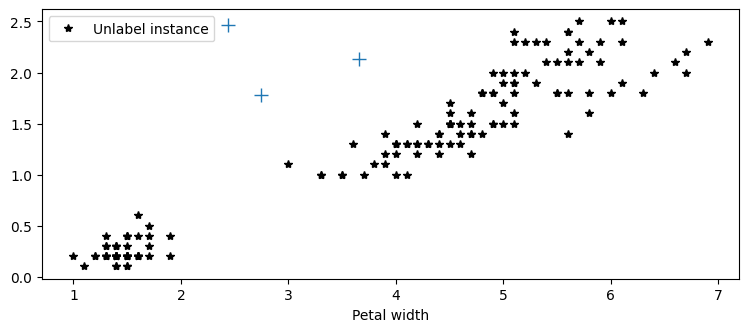

In [60]:
showplot(centroids)

In [61]:
from matplotlib import pyplot as plt

def showplotwithclass(sorted_x, centroids):
    plt.figure(figsize=(9, 3.5))

    colors = plt.cm.tab20.colors

    for i, cluster_points in enumerate(sorted_x):
        if len(cluster_points) == 0:  # Skip empty clusters
            continue
        cluster_points = np.array(cluster_points)
        plt.plot(
            cluster_points[:, 0],
            cluster_points[:, 1],
            marker="o",
            linestyle="",
            color=colors[i % len(colors)],
            label=f"Class {i + 1} instances",
        )

    plt.plot(
        [x for x, _ in centroids],
        [y for _, y in centroids],
        "k+",
        markersize=10,
        label="Centroids",
    )

    plt.xlabel("Petal length", fontsize=10)
    plt.ylabel("Petal width", fontsize=10)
    plt.legend(fontsize=10)
    plt.show()

In [62]:
def calculateClass(X, centroids):
  sorted_x = [[] for _ in range(n_clusters)]  # Independent lists
  for x in X:
    dists = [euclidean(x, centroid) for centroid in centroids]
    centroid_idx = np.argmin(dists)
    sorted_x[centroid_idx].append(x)

  sorted_x = [np.array(cluster) for cluster in sorted_x]

  showplotwithclass(sorted_x, centroids)
  return sorted_x

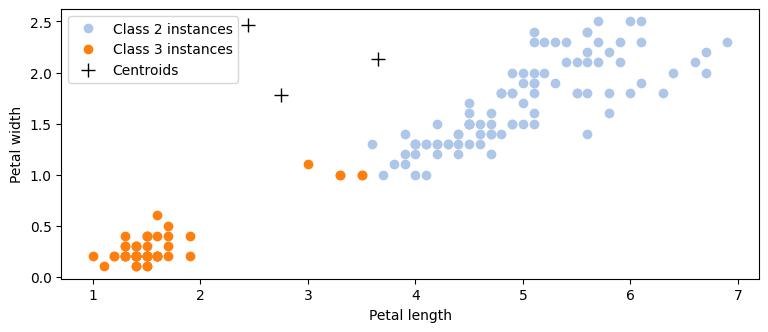

In [63]:
res = calculateClass(X, centroids)

/Users/kitton/Desktop/Workspace/github/intro-to-ml-and-dl/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kitton/Desktop/Workspace/github/intro-to-ml-and-dl/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


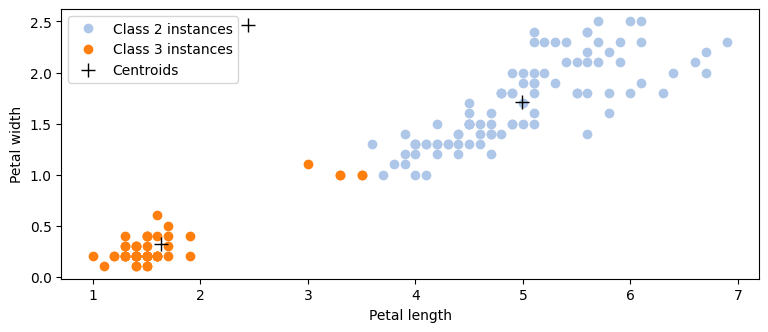

In [64]:
# After that, we use the result to adjust the current centroid.
# Reassign centroids as the mean of the points belonging to them.
def adjustCentroid(sorted_x, centroids):
    prev_centroids = centroids
    centroids = [np.mean(cluster, axis=0) for cluster in sorted_x]
    for i, centroid in enumerate(centroids):
        if np.isnan(
            centroid
        ).any():  # Catch any np.nans, resulting from a centroid having no points
            centroids[i] = prev_centroids[i]

    showplotwithclass(sorted_x, centroids)
    return centroids


res = adjustCentroid(res, centroids)

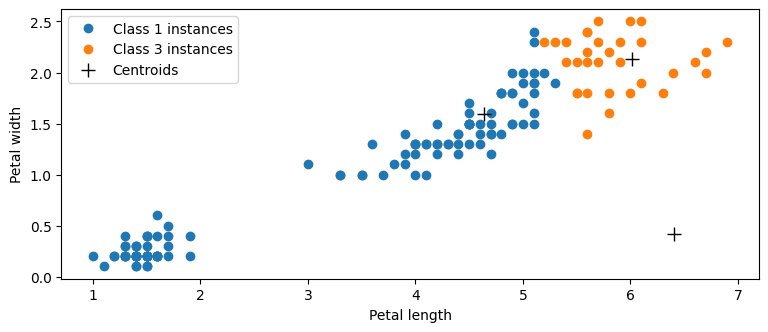

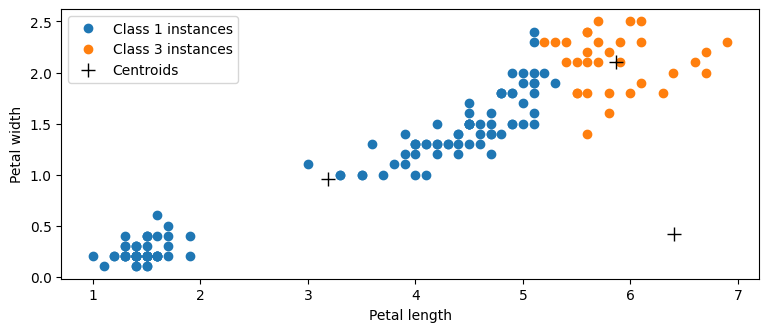

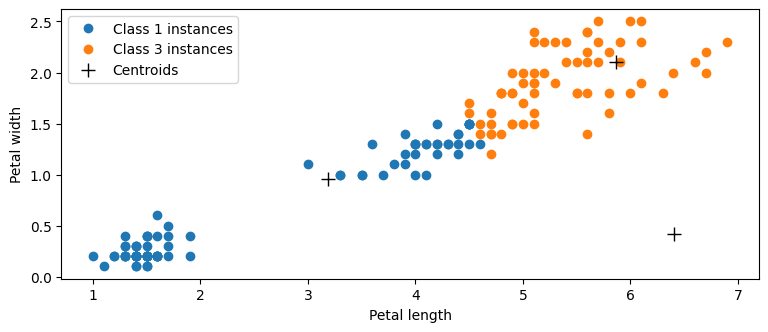

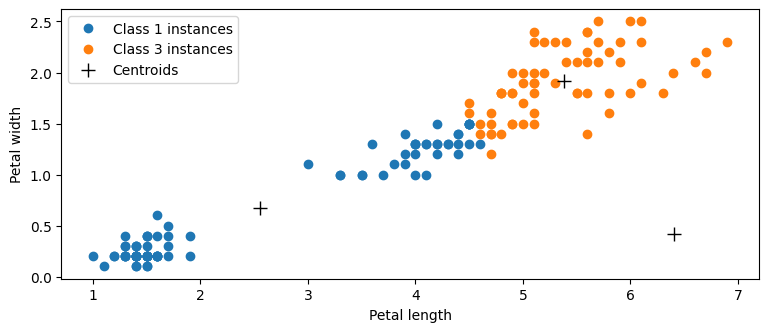

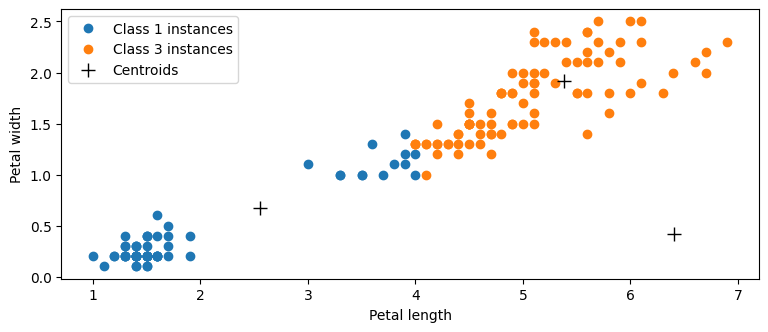

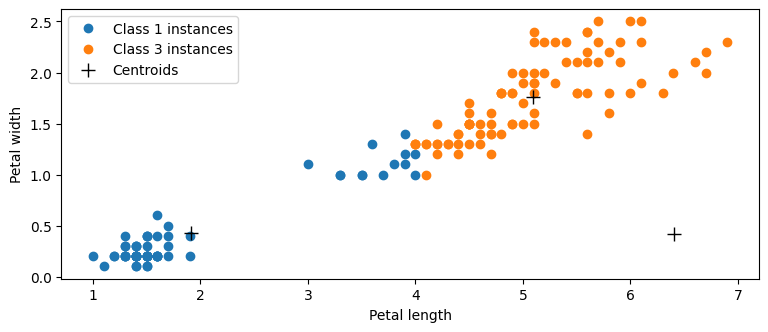

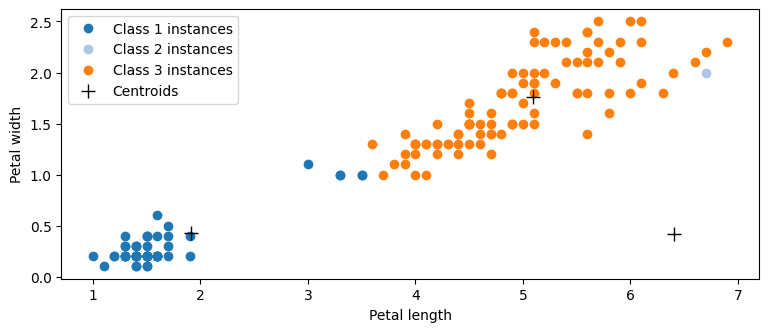

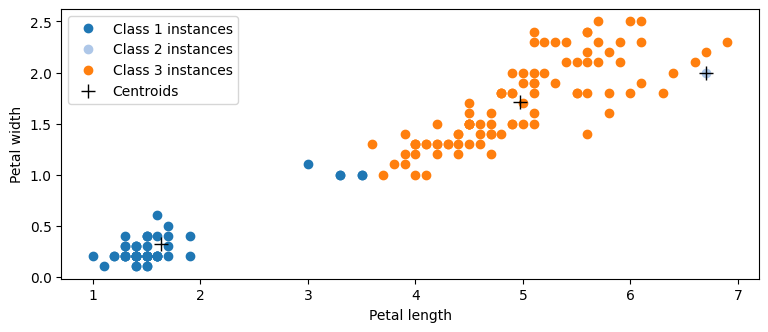

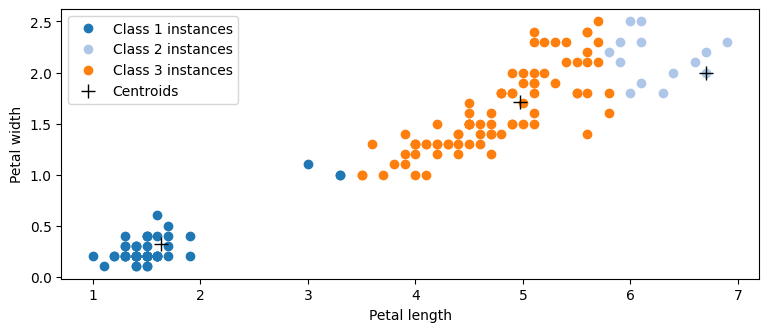

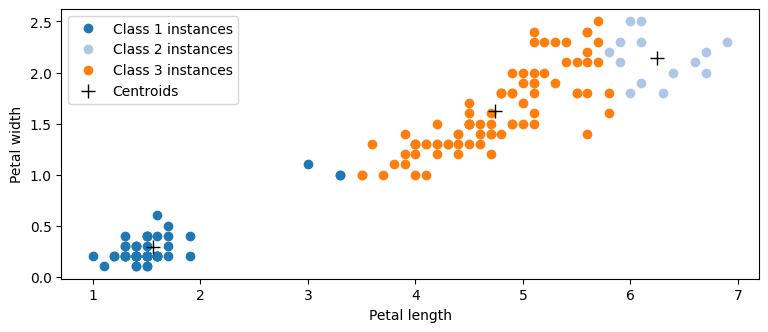

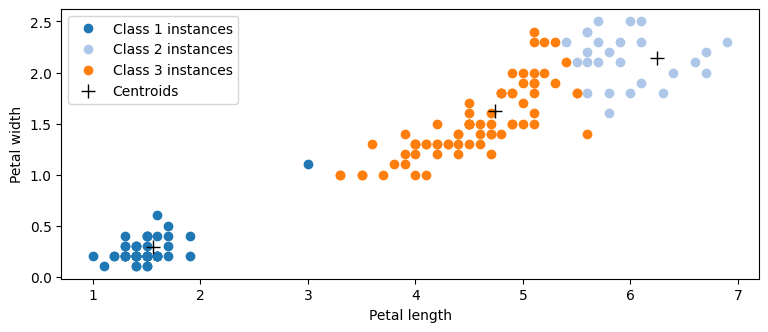

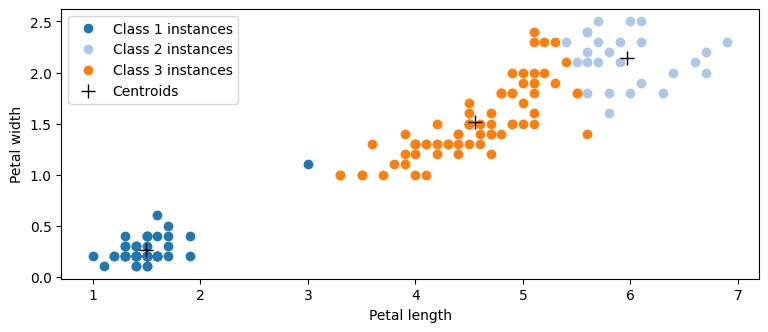

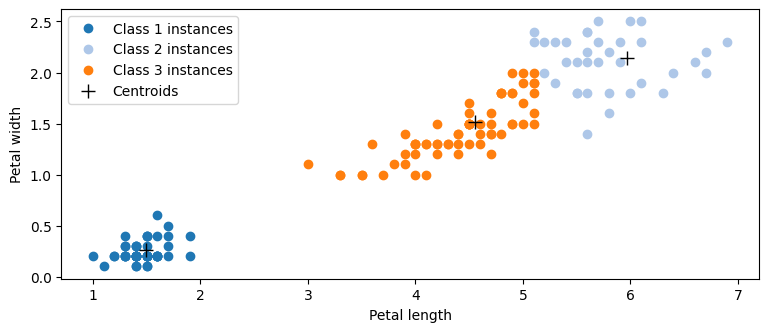

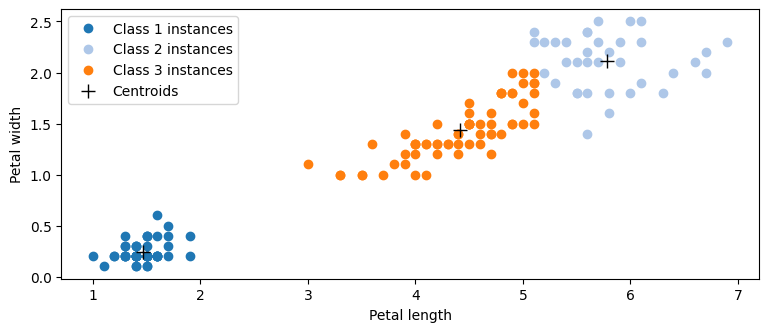

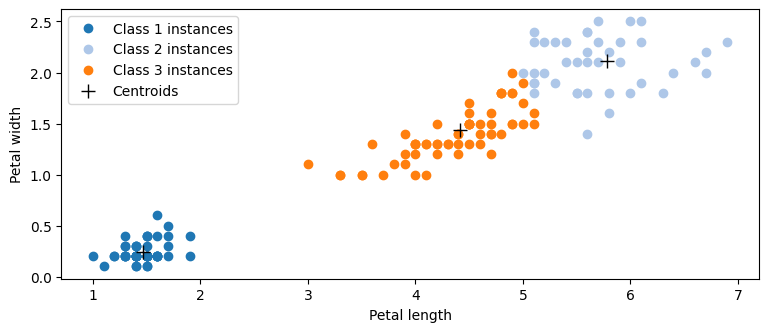

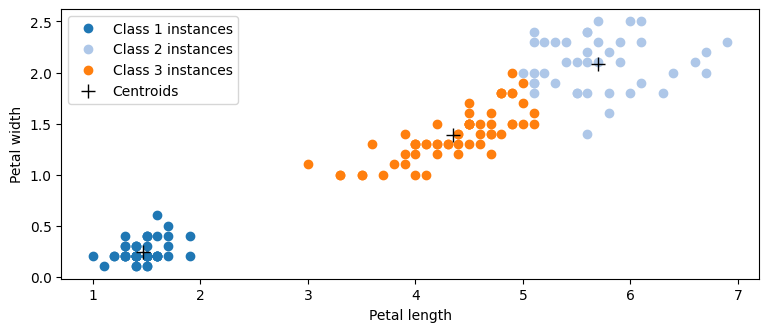

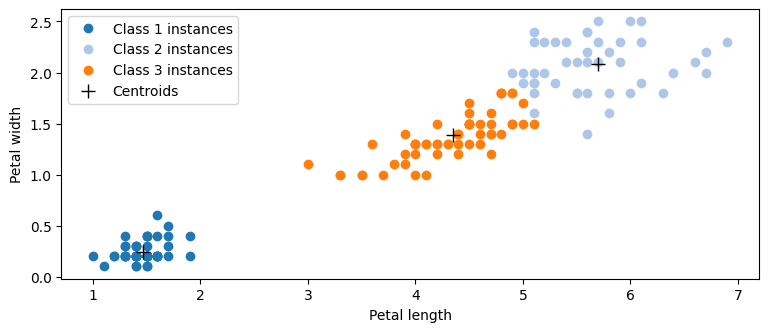

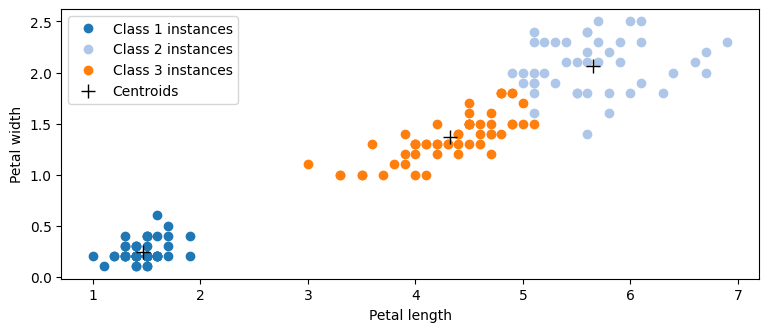

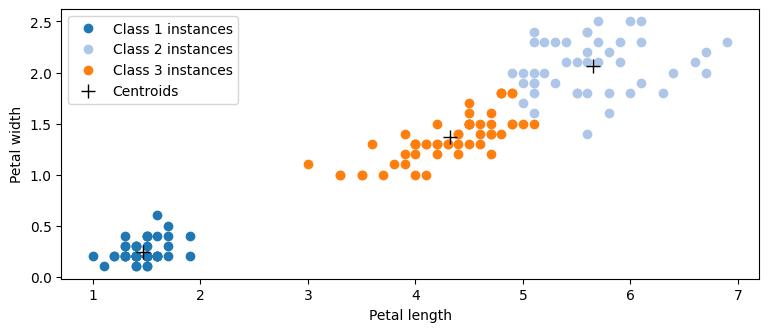

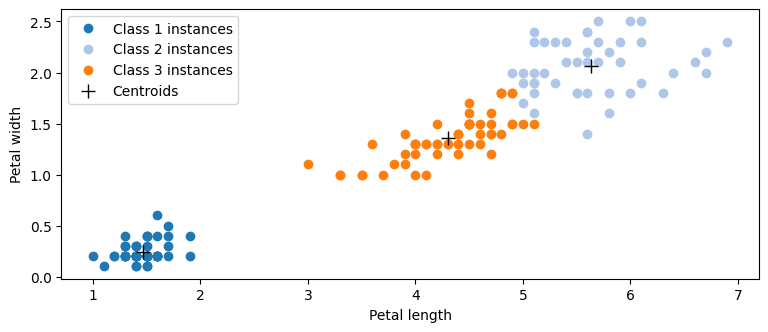

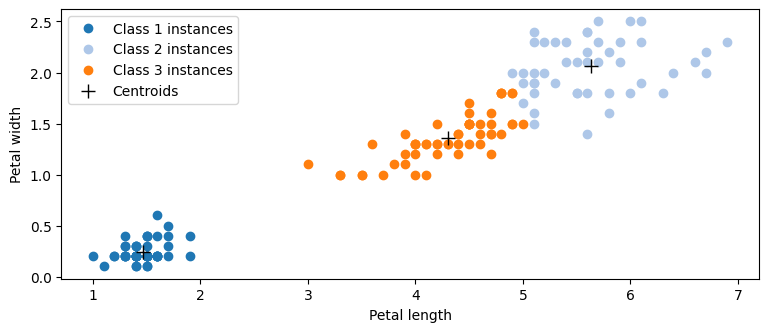

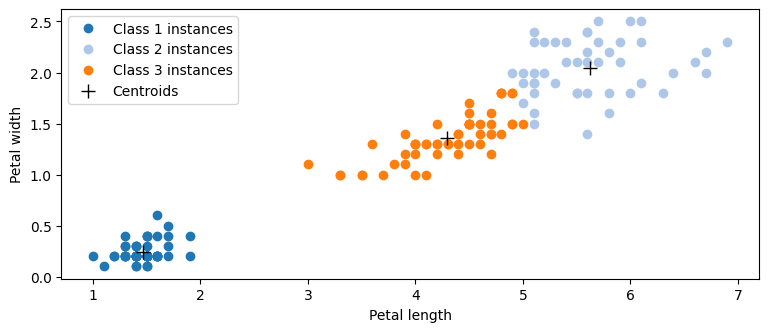

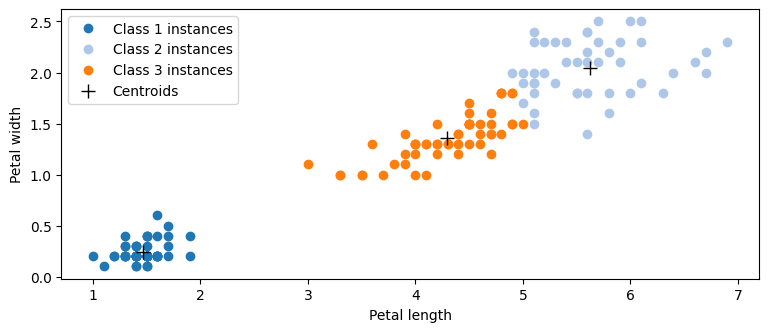

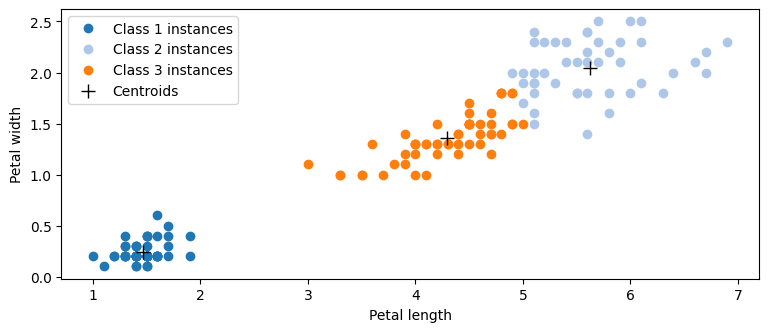

In [ ]:
# We will create a computation loop like this.
def train(X, n_clusters):
    minpoint, maxpoint = np.min(X[:, :], axis=0), np.max(X[:, :], axis=0)
    centroids = np.array(
        [uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)]
    )
    while True:
        sorted_x = calculateClass(X, centroids)
        new_centroid = adjustCentroid(sorted_x, centroids)
        if np.allclose(centroids, new_centroid):
            break
        centroids = new_centroid


train(X, 3)

In [ ]:
def train(X, n_clusters):
    minpoint, maxpoint = np.min(X, axis=0), np.max(X, axis=0)
    centroids = np.array(
        [uniform(low=minpoint, high=maxpoint) for _ in range(n_clusters)]
    )

    while True:
        sorted_x = calculateClass(X, centroids)
        new_centroid = adjustCentroid(sorted_x, centroids)
        if np.allclose(centroids, new_centroid):
            break
        centroids = new_centroid

    labels = np.zeros(X.shape[0], dtype=int)
    for cluster_index, rows in enumerate(sorted_x):
        for row in rows:
            idx = np.where(np.all(X == row, axis=1))[0][0]
            labels[idx] = cluster_index
    return labels


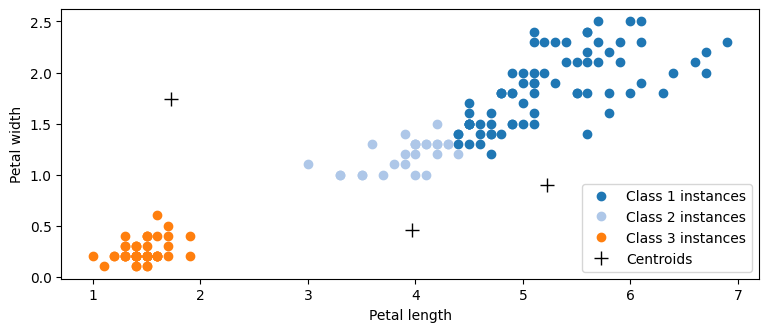

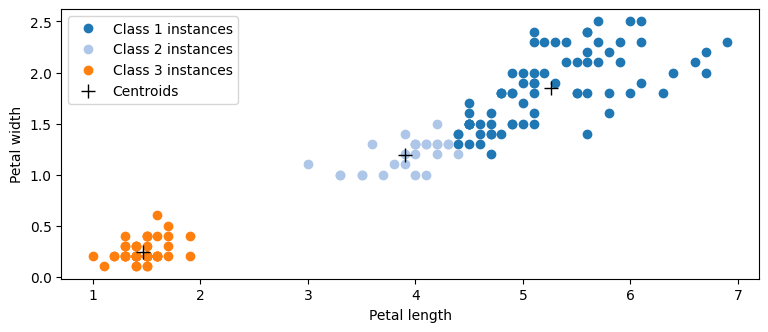

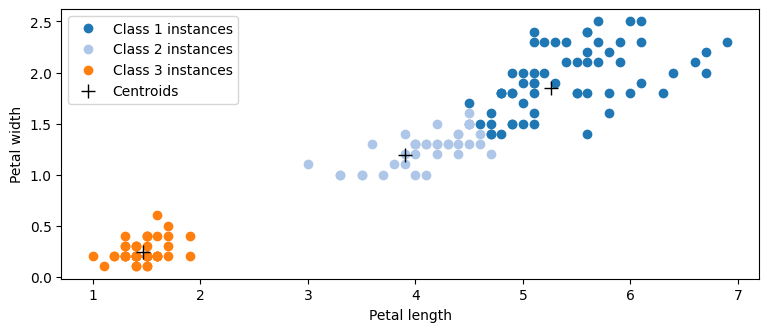

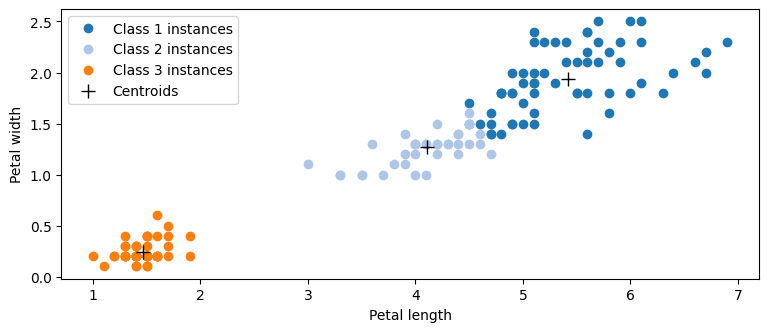

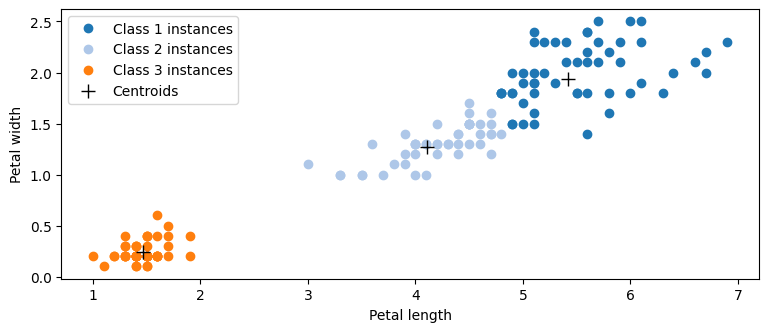

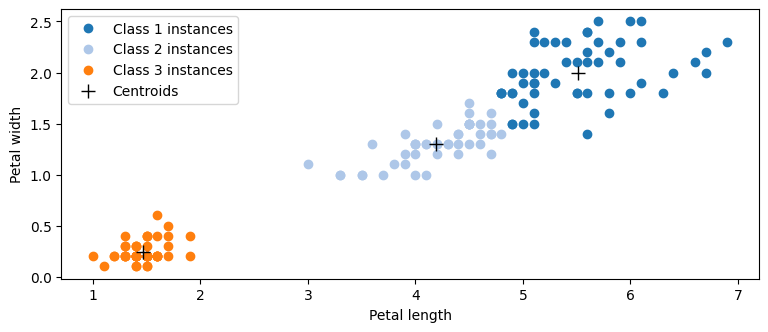

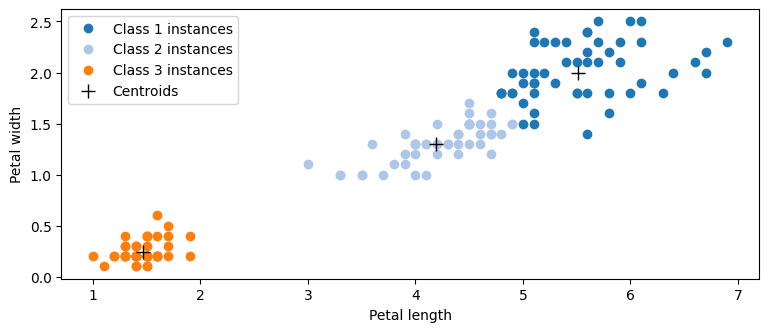

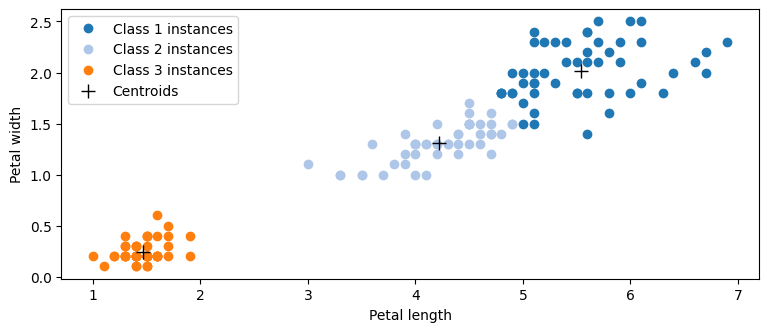

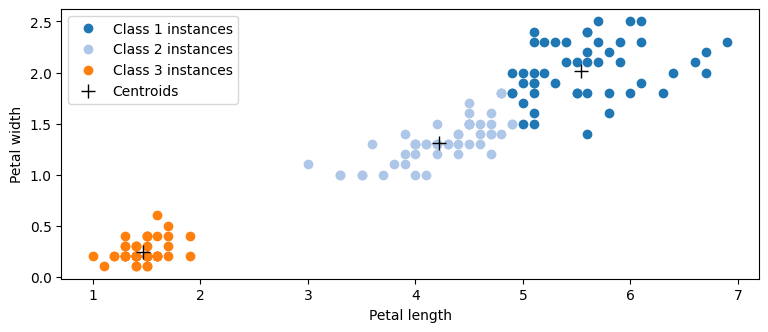

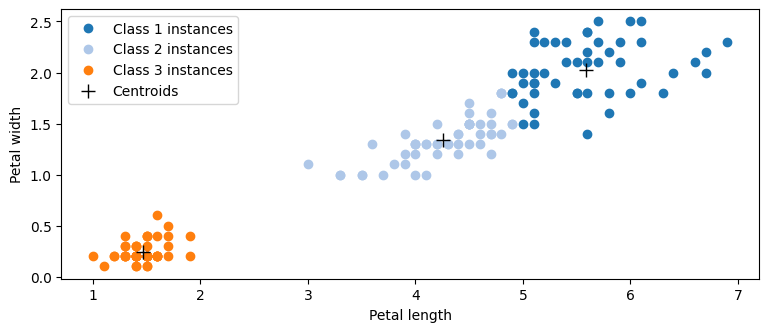

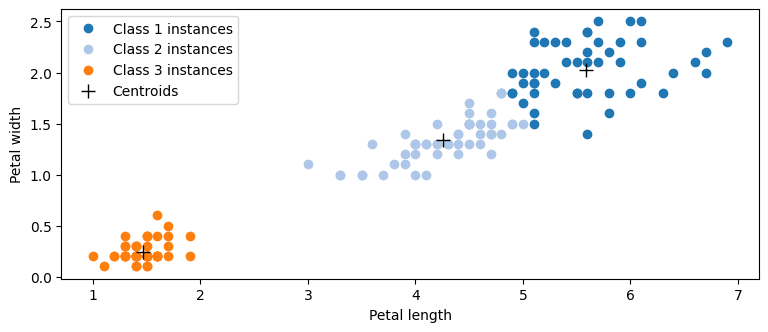

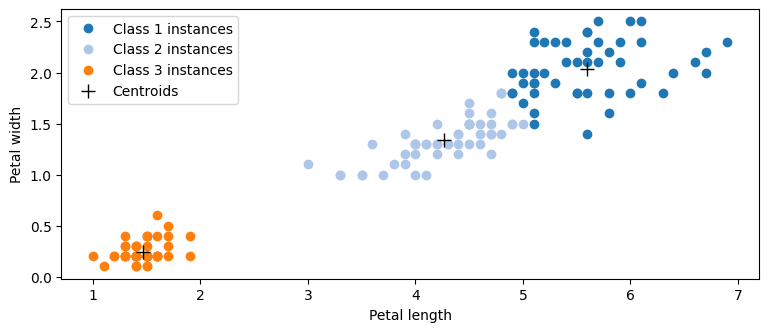

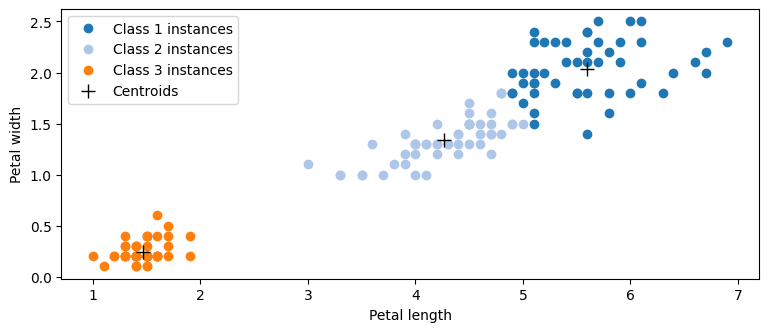

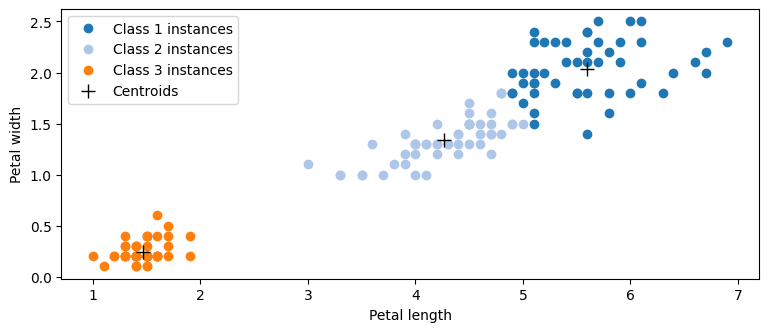

K-Means Accuracy: 0.6933333333333334


In [72]:
labels = train(X, 3)

acc = cluster_accuracy(y, labels)
print("K-Means Accuracy:", acc)
